HurryWave spectral file
Start : 2024-09-23T00:00:00.000000000
End   : 2024-09-27T18:00:00.000000000
Deltat: 3600.0 s
Hm0 max from spectra: 11.771617135247112
Skipped first 10 spectral stations (NDBC buoys)

HurryWave bulk file
Skipped first 10 bulk stations (NDBC buoys)

Hm0 bias (m)                  0.024585
Hm0 RMSE (m)                  0.135211
Tp bias (s)                  -0.353186
Tp RMSE (s)                   2.166805
Peak dir FROM bias (deg)      0.182875
Peak dir FROM RMSE (deg)    134.564009
Peak dir TO bias (deg)        0.182875
Peak dir TO RMSE (deg)      134.564009
dtype: float64
<xarray.Dataset> Size: 4MB
Dimensions:              (time: 115, point: 415)
Coordinates:
  * time                 (time) datetime64[ns] 920B 2024-09-23 ... 2024-09-27...
  * point                (point) int64 3kB 0 1 2 3 4 5 ... 410 411 412 413 414
Data variables: (12/21)
    lon                  (point) float64 3kB -88.0 -87.98 ... -82.48 -82.47
    lat                  (point) float64 3kB 29.96 2

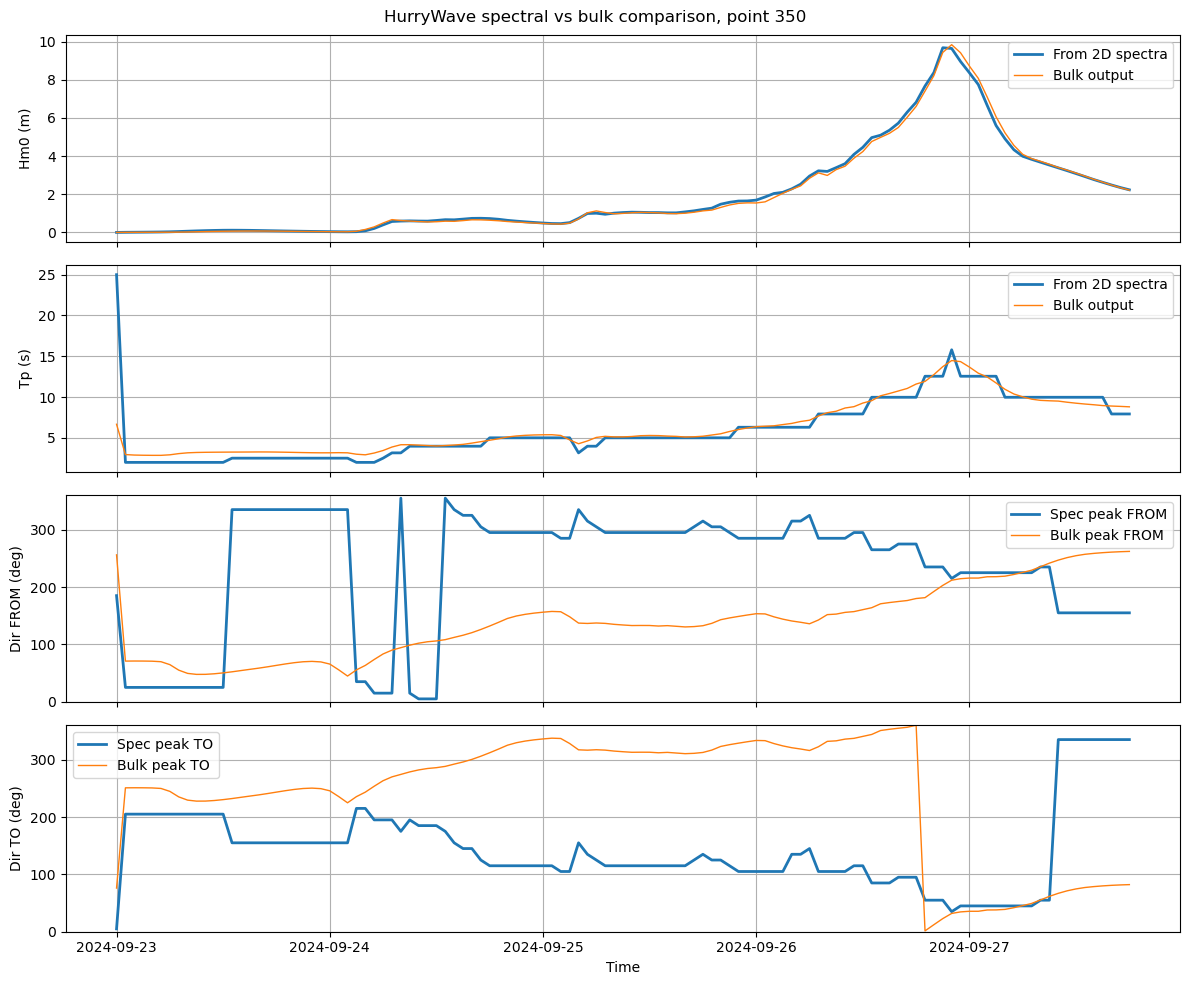

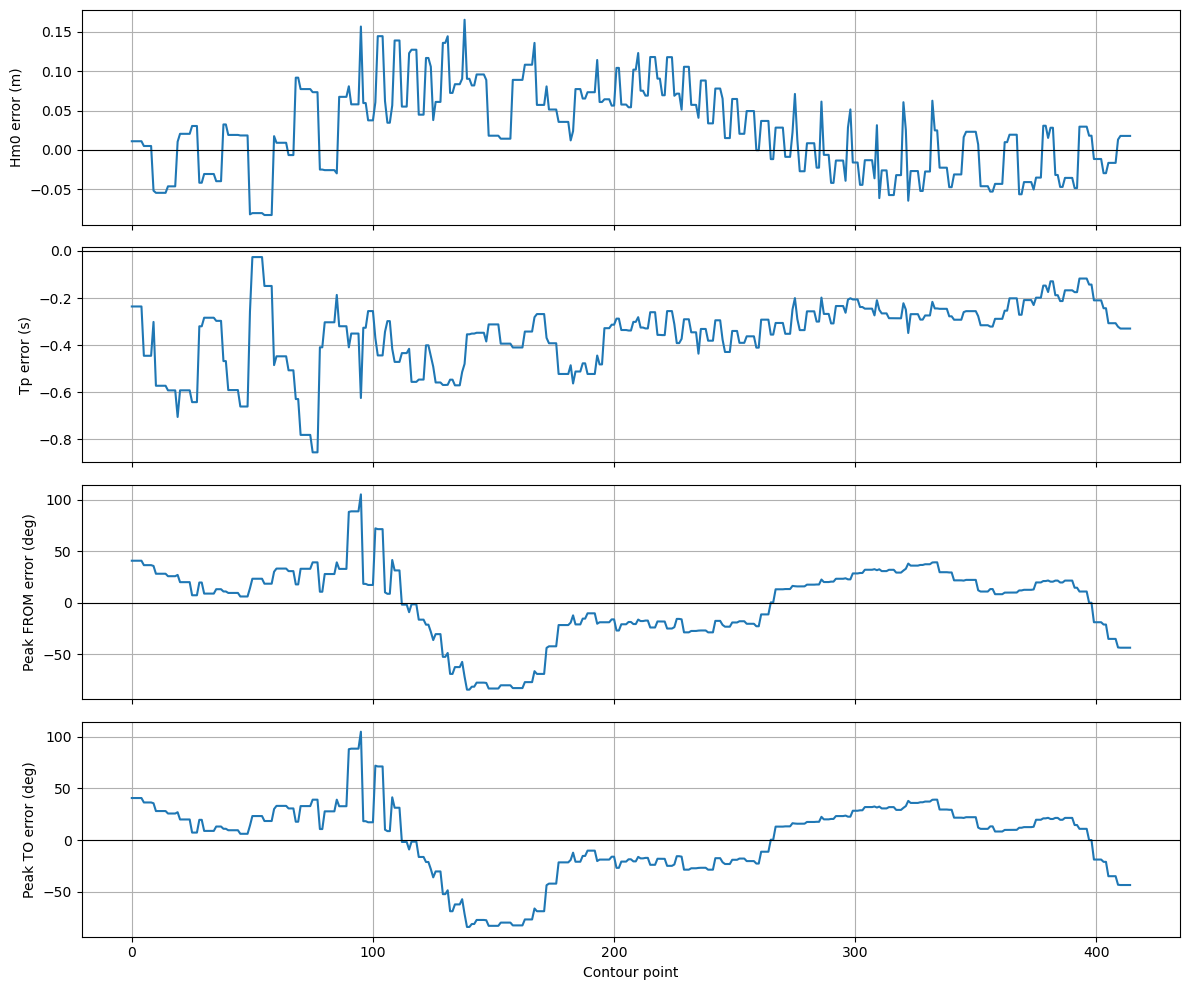

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# ============================================================
# 1. CONTOUR UTILITIES
# ============================================================

def read_contour(contour_file):
    """
    Read contour points and stored normals from CSV.

    Expected columns:
      contour30s_lon, contour30s_lat, contour30s_x, contour30s_y,
      normals30_x, normals30_y

    Stored normals are assumed to point offshore, so they are flipped
    here to give shoreward normals.
    """
    df = pd.read_csv(contour_file)

    ds = xr.Dataset(
        coords={"point": np.arange(len(df))},
        data_vars={
            "lon":      ("point", df["contour30s_lon"].to_numpy()),
            "lat":      ("point", df["contour30s_lat"].to_numpy()),
            "x":        ("point", df["contour30s_x"].to_numpy()),
            "y":        ("point", df["contour30s_y"].to_numpy()),
            "normal_x": ("point", -df["normals30_x"].to_numpy()),
            "normal_y": ("point", -df["normals30_y"].to_numpy()),
        }
    )
    return ds


def attach_contour(ds, contour_ds):
    """
    Attach contour coordinates and normals to a dataset with dimension 'point'.
    Assumes point order already matches.
    """
    npt = min(ds.sizes["point"], contour_ds.sizes["point"])
    ds = ds.isel(point=slice(0, npt)).copy()
    contour_ds = contour_ds.isel(point=slice(0, npt))

    for v in ["lon", "lat", "x", "y", "normal_x", "normal_y"]:
        if v in contour_ds:
            ds[v] = ("point", contour_ds[v].values)

    return ds


# ============================================================
# 2. ANGLE UTILITIES
# ============================================================

def wrap360(deg):
    return np.mod(deg, 360.0)


def circ_diff_deg(a, b):
    """
    Signed shortest angular difference a-b in degrees.
    """
    return (a - b + 180.0) % 360.0 - 180.0


def to_to_from(dir_to_deg):
    """
    Convert geographic/nautical TO direction to FROM direction.
    """
    return wrap360(dir_to_deg + 180.0)


def from_to_to(dir_from_deg):
    """
    Convert geographic/nautical FROM direction to TO direction.
    """
    return wrap360(dir_from_deg + 180.0)


def weighted_circular_mean_deg(dir_deg, weights, axis=-1):
    """
    Weighted circular mean of geographic angles in degrees.
    """
    th = np.deg2rad(dir_deg)
    s = np.sum(weights * np.sin(th), axis=axis)
    c = np.sum(weights * np.cos(th), axis=axis)
    return wrap360(np.rad2deg(np.arctan2(s, c)))


# ============================================================
# 3. READ HURRYWAVE 2D SPECTRA
# ============================================================

def read_hurrywave_2dspec(nc_path, contour_ds=None, nskip=10):
    """
    Read HurryWave 2D spectra.

    Notes
    -----
    - Native dims: (time, stations, theta, sigma)
    - theta is treated here as geographic TO direction (degrees)
    - output spec units are m^2/Hz/rad
    - first `nskip` stations are omitted (NDBC buoys)
    """
    ds0 = xr.open_dataset(nc_path, mask_and_scale=True, decode_cf=True)

    time = ds0["time"].values
    f = ds0["sigma"].values                    # Hz
    omega = f * 2.0 * np.pi                   # rad/s
    dir_to_deg = ds0["theta"].values          # degrees TO

    # native shape: (time, stations, theta, sigma)
    S = ds0["point_spectrum2d"].values[:, nskip:, :, :]

    # convert to energy density using omega
    S = S * omega[np.newaxis, np.newaxis, np.newaxis, :]

    # convert from per-(rad/s) to per-Hz
    S = S * (2.0 * np.pi)

    # reorder to (time, point, freq, dir)
    S = np.transpose(S, (0, 1, 3, 2))

    ds = xr.Dataset(
        coords={
            "time": time,
            "point": np.arange(S.shape[1]),
            "freq": f,
            "dir": dir_to_deg,
        },
        data_vars={
            "spec": (("time", "point", "freq", "dir"), S),
        },
        attrs={
            "model": "Hurrywave",
            "dir_convention": "to",
            "spec_units": "m^2/Hz/rad",
            "spectral_station_offset": nskip,
        }
    )

    if contour_ds is not None:
        ds = attach_contour(ds, contour_ds)

    return ds


# ============================================================
# 4. SPECTRAL BULK STATS
# ============================================================

def calc_hm0(ds):
    """
    Add m0 and hm0 from 2D spectra.
    Assumes spec is in m^2/Hz/rad and dir is in degrees.
    """
    f = ds["freq"].values
    ddir_deg = float(np.nanmean(np.diff(ds["dir"].values)))
    dtheta = np.deg2rad(ddir_deg)

    S = ds["spec"].values                         # (time, point, freq, dir)
    Ef = np.sum(S, axis=-1) * dtheta             # (time, point, freq)
    m0 = np.trapezoid(Ef, x=f, axis=-1)
    hm0 = 4.0 * np.sqrt(np.maximum(m0, 0.0))

    ds["m0"] = (("time", "point"), m0)
    ds["hm0"] = (("time", "point"), hm0)
    ds["hm0"].attrs["units"] = "m"
    return ds


def calc_bulk_from_2dspec(ds):
    """
    Compute bulk statistics from HurryWave 2D spectra.

    Spectral directions are treated as TO directions.

    Returns both TO and FROM conventions for mean and peak directions.
    """
    S = ds["spec"].values            # (time, point, freq, dir)
    f = ds["freq"].values
    d_to = ds["dir"].values

    ddir_deg = float(np.nanmean(np.diff(d_to)))
    dtheta = np.deg2rad(ddir_deg)

    # 1D spectrum
    Ef = np.sum(S, axis=-1) * dtheta            # (time, point, freq)

    m0 = np.trapezoid(Ef, x=f, axis=-1)
    hm0 = 4.0 * np.sqrt(np.maximum(m0, 0.0))

    # Tp from peak of 1D spectrum
    ipk_f = np.nanargmax(Ef, axis=-1)           # (time, point)
    fp = f[ipk_f]
    tp = np.where(fp > 0, 1.0 / fp, np.nan)

    # Mean TO direction, frequency-integrated directional distribution
    Edir = np.trapezoid(S, x=f, axis=2)         # (time, point, dir)
    wdir_mean_to = weighted_circular_mean_deg(
        d_to[None, None, :], Edir, axis=-1
    )
    wdir_mean_from = to_to_from(wdir_mean_to)

    # Peak TO direction:
    # direction of maximum energy at the peak frequency
    nt, npnt, nf, nd = S.shape
    wdir_peak_to = np.full((nt, npnt), np.nan, dtype=float)

    for it in range(nt):
        for ip in range(npnt):
            jf = ipk_f[it, ip]
            sdir = S[it, ip, jf, :]
            if np.all(~np.isfinite(sdir)):
                continue
            jd = int(np.nanargmax(sdir))
            wdir_peak_to[it, ip] = d_to[jd]

    wdir_peak_from = to_to_from(wdir_peak_to)

    out = xr.Dataset(
        coords={
            "time": ds["time"],
            "point": ds["point"],
        },
        data_vars={
            "m0_spec":               (("time", "point"), m0),
            "hm0_spec":              (("time", "point"), hm0),
            "tp_spec":               (("time", "point"), tp),

            "wdir_mean_to_spec":     (("time", "point"), wdir_mean_to),
            "wdir_mean_from_spec":   (("time", "point"), wdir_mean_from),

            "wdir_peak_to_spec":     (("time", "point"), wdir_peak_to),
            "wdir_peak_from_spec":   (("time", "point"), wdir_peak_from),
        }
    )

    for v in ["lon", "lat", "x", "y", "normal_x", "normal_y"]:
        if v in ds:
            out[v] = ds[v]

    return out


# ============================================================
# 5. HURRYWAVE BULK OUTPUT
# ============================================================

def read_hurrywave_bulk(his_nc_path, contour_ds=None, nskip=10):
    """
    Read HurryWave bulk output from hurrywave_his.nc.

    Uses:
      point_hm0
      point_tp
      point_wavdir   (peak FROM direction, degrees)

    Notes
    -----
    The first `nskip` stations are omitted because they correspond to
    NDBC buoy locations rather than contour points.

    Returns both FROM and TO conventions.
    """
    ds0 = xr.open_dataset(his_nc_path, mask_and_scale=True, decode_cf=True)

    hm0_bulk = ds0["point_hm0"].isel(stations=slice(nskip, None))
    tp_bulk = ds0["point_tp"].isel(stations=slice(nskip, None))
    wdir_peak_from_bulk = ds0["point_wavdir"].isel(stations=slice(nskip, None))

    npt = hm0_bulk.sizes["stations"]

    out = xr.Dataset(
        coords={
            "time": ds0["time"].values,
            "point": np.arange(npt),
        },
        data_vars={
            "hm0_bulk": (("time", "point"), hm0_bulk.values),
            "tp_bulk": (("time", "point"), tp_bulk.values),

            "wdir_peak_from_bulk": (("time", "point"), wdir_peak_from_bulk.values),
            "wdir_peak_to_bulk": (
                ("time", "point"),
                from_to_to(wdir_peak_from_bulk.values)
            ),
        },
        attrs={
            "model": "Hurrywave bulk",
            "dir_convention": "from",
            "bulk_station_offset": nskip,
        }
    )

    if contour_ds is not None:
        out = attach_contour(out, contour_ds)

    return out


# ============================================================
# 6. BUILD COMPARISON DATASET
# ============================================================

def build_hurrywave_spec_vs_bulk_comparison(
    sp2_nc_path,
    his_nc_path,
    contour_ds,
    nskip=10,
):
    ds_spec2d = read_hurrywave_2dspec(
        sp2_nc_path,
        contour_ds=contour_ds,
        nskip=nskip,
    )
    ds_spec2d = calc_hm0(ds_spec2d)
    ds_specbulk = calc_bulk_from_2dspec(ds_spec2d)

    ds_bulk = read_hurrywave_bulk(
        his_nc_path,
        contour_ds=contour_ds,
        nskip=nskip,
    )

    # Align spectral points with bulk contour-point subset
    npt = min(ds_specbulk.sizes["point"], ds_bulk.sizes["point"])
    ds_specbulk = ds_specbulk.isel(point=slice(0, npt))
    ds_bulk = ds_bulk.isel(point=slice(0, npt))

    ds_specbulk, ds_bulk = xr.align(ds_specbulk, ds_bulk, join="inner")

    ds_cmp = xr.Dataset(
        coords={
            "time": ds_specbulk["time"],
            "point": ds_specbulk["point"],
        }
    )

    for v in ["lon", "lat", "x", "y", "normal_x", "normal_y"]:
        if v in ds_specbulk:
            ds_cmp[v] = ds_specbulk[v]

    for v in ds_specbulk.data_vars:
        if v not in ds_cmp:
            ds_cmp[v] = ds_specbulk[v]

    for v in ds_bulk.data_vars:
        ds_cmp[v] = ds_bulk[v]

    ds_cmp["d_hm0"] = ds_cmp["hm0_spec"] - ds_cmp["hm0_bulk"]
    ds_cmp["d_tp"] = ds_cmp["tp_spec"] - ds_cmp["tp_bulk"]

    # Compare peak directions in both conventions
    ds_cmp["d_wdir_peak_from"] = xr.apply_ufunc(
        circ_diff_deg,
        ds_cmp["wdir_peak_from_spec"],
        ds_cmp["wdir_peak_from_bulk"],
        vectorize=True,
    )

    ds_cmp["d_wdir_peak_to"] = xr.apply_ufunc(
        circ_diff_deg,
        ds_cmp["wdir_peak_to_spec"],
        ds_cmp["wdir_peak_to_bulk"],
        vectorize=True,
    )

    return ds_spec2d, ds_specbulk, ds_bulk, ds_cmp


# ============================================================
# 7. SUMMARY STATS
# ============================================================

def rmse(a):
    a = np.asarray(a, dtype=float)
    return np.sqrt(np.nanmean(a**2))


def summary_stats(ds_cmp):
    return pd.Series({
        "Hm0 bias (m)": float(np.nanmean(ds_cmp["d_hm0"].values)),
        "Hm0 RMSE (m)": float(rmse(ds_cmp["d_hm0"].values)),
        "Tp bias (s)": float(np.nanmean(ds_cmp["d_tp"].values)),
        "Tp RMSE (s)": float(rmse(ds_cmp["d_tp"].values)),
        "Peak dir FROM bias (deg)": float(np.nanmean(ds_cmp["d_wdir_peak_from"].values)),
        "Peak dir FROM RMSE (deg)": float(rmse(ds_cmp["d_wdir_peak_from"].values)),
        "Peak dir TO bias (deg)": float(np.nanmean(ds_cmp["d_wdir_peak_to"].values)),
        "Peak dir TO RMSE (deg)": float(rmse(ds_cmp["d_wdir_peak_to"].values)),
    })


# ============================================================
# 8. PLOTTING
# ============================================================

def plot_hurrywave_timeseries(ds_cmp, point=350):
    t = ds_cmp["time"].values

    fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    ax[0].plot(t, ds_cmp["hm0_spec"][:, point], label="From 2D spectra", lw=2)
    ax[0].plot(t, ds_cmp["hm0_bulk"][:, point], label="Bulk output", lw=1)
    ax[0].set_ylabel("Hm0 (m)")
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(t, ds_cmp["tp_spec"][:, point], label="From 2D spectra", lw=2)
    ax[1].plot(t, ds_cmp["tp_bulk"][:, point], label="Bulk output", lw=1)
    ax[1].set_ylabel("Tp (s)")
    ax[1].grid(True)
    ax[1].legend()

    ax[2].plot(t, ds_cmp["wdir_peak_from_spec"][:, point], label="Spec peak FROM", lw=2)
    ax[2].plot(t, ds_cmp["wdir_peak_from_bulk"][:, point], label="Bulk peak FROM", lw=1)
    ax[2].set_ylabel("Dir FROM (deg)")
    ax[2].set_ylim(0, 360)
    ax[2].grid(True)
    ax[2].legend()

    ax[3].plot(t, ds_cmp["wdir_peak_to_spec"][:, point], label="Spec peak TO", lw=2)
    ax[3].plot(t, ds_cmp["wdir_peak_to_bulk"][:, point], label="Bulk peak TO", lw=1)
    ax[3].set_ylabel("Dir TO (deg)")
    ax[3].set_xlabel("Time")
    ax[3].set_ylim(0, 360)
    ax[3].grid(True)
    ax[3].legend()

    fig.suptitle(f"HurryWave spectral vs bulk comparison, point {point}")
    fig.tight_layout()
    return fig, ax


def plot_hurrywave_mean_errors(ds_cmp):
    p = ds_cmp["point"].values

    fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    ax[0].plot(p, ds_cmp["d_hm0"].mean("time"))
    ax[0].axhline(0, color="k", lw=0.8)
    ax[0].set_ylabel("Hm0 error (m)")
    ax[0].grid(True)

    ax[1].plot(p, ds_cmp["d_tp"].mean("time"))
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].set_ylabel("Tp error (s)")
    ax[1].grid(True)

    ax[2].plot(p, ds_cmp["d_wdir_peak_from"].mean("time"))
    ax[2].axhline(0, color="k", lw=0.8)
    ax[2].set_ylabel("Peak FROM error (deg)")
    ax[2].grid(True)

    ax[3].plot(p, ds_cmp["d_wdir_peak_to"].mean("time"))
    ax[3].axhline(0, color="k", lw=0.8)
    ax[3].set_ylabel("Peak TO error (deg)")
    ax[3].set_xlabel("Contour point")
    ax[3].grid(True)

    fig.tight_layout()
    return fig, ax


# ============================================================
# 9. RUN
# ============================================================

contour_file = "contour30sp.csv"
contour_ds = read_contour(contour_file)

data_dir = "F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/helene89pervmax/"
sp2_nc_path = data_dir + "hurrywave_sp2.nc"
his_nc_path = data_dir + "hurrywave_his.nc"

ds_hw_spec2d, ds_hw_specbulk, ds_hw_bulk, ds_hw_cmp = build_hurrywave_spec_vs_bulk_comparison(
    sp2_nc_path=sp2_nc_path,
    his_nc_path=his_nc_path,
    contour_ds=contour_ds,
    nskip=10,
)

print("HurryWave spectral file")
time = ds_hw_spec2d["time"].values
dt = (time[1] - time[0]) / np.timedelta64(1, "s")
print("Start :", time[0])
print("End   :", time[-1])
print("Deltat:", dt, "s")
print("Hm0 max from spectra:", np.nanmax(ds_hw_spec2d["hm0"].values))
print("Skipped first 10 spectral stations (NDBC buoys)")
print()

print("HurryWave bulk file")
print("Skipped first 10 bulk stations (NDBC buoys)")
print()

print(summary_stats(ds_hw_cmp))
print(ds_hw_cmp)

fig1, ax1 = plot_hurrywave_timeseries(ds_hw_cmp, point=350)
fig2, ax2 = plot_hurrywave_mean_errors(ds_hw_cmp)
plt.show()